<a href="https://colab.research.google.com/github/Manemitio811/Neural-network-systems-/blob/main/%D0%9B%D0%A01_%D0%9A%D0%BB%D0%B8%D1%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Создание схемы нейронной сети согласно варианту таблицы

Рассмотрим двухслойную нейронную сеть следующей структуры:
- **Входной слой:** 1 вход ($x_1$).
- **Скрытый слой (первый):** 17 нейронов, функция активации — сигмоида: $P(S) = \frac{1}{1 + e^{-S}}$.
- **Выходной слой (второй):** 1 нейрон, функция активации — ReLU: $Y(S) = \max(0, S)$

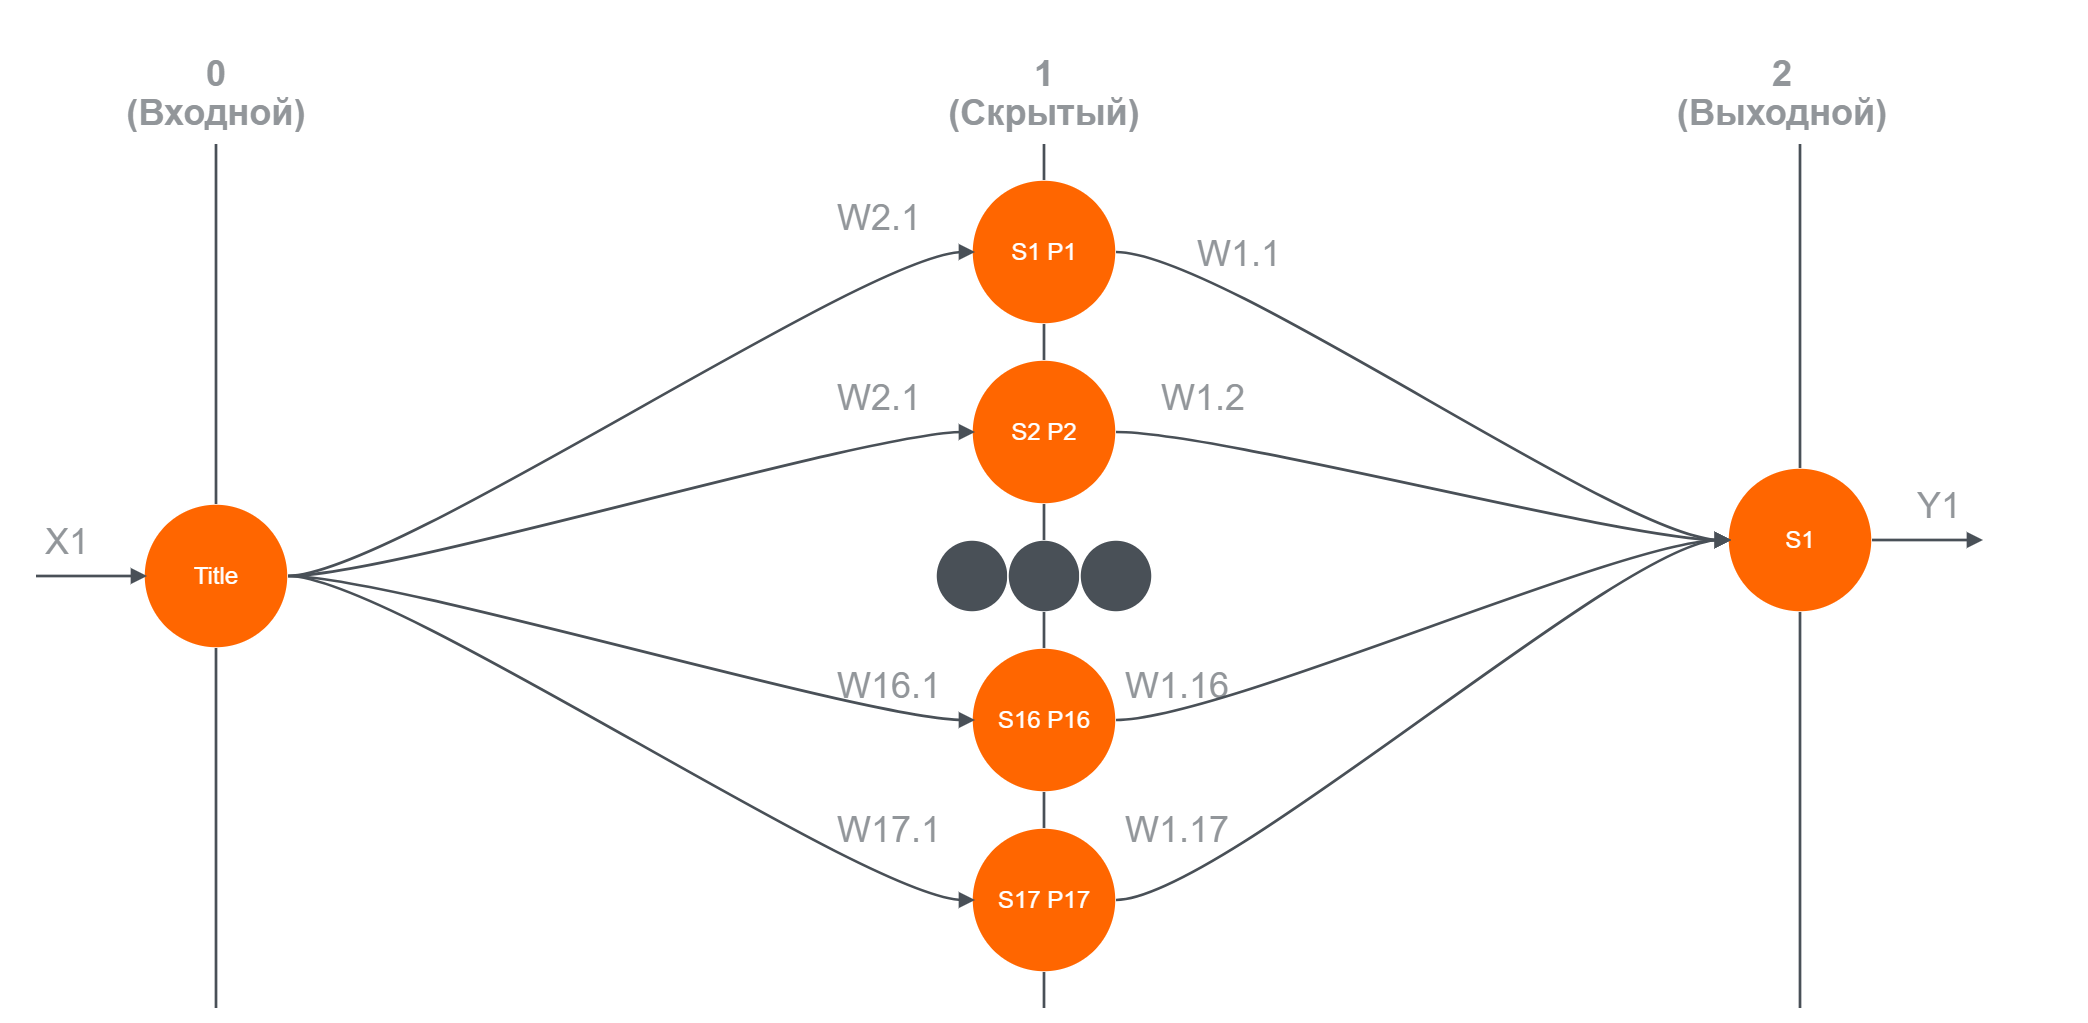

### 2. Создание математической модели нейронной сети согласно варианту

### 1. Первый (скрытый) слой

В этом слое каждый нейрон $j$ вычисляет взвешенную сумму входов $S_j^{(1)}$, а затем применяет к ней сигмоидную функцию активации для получения выхода $P_j$.

**Развернутая запись для каждого нейрона:**

**Первый нейрон скрытого слоя ($j=1$):**
$$ S_1^{(1)} = x_1 \cdot w_{1.1}^{(1)} $$
$$ P_1 = \frac{1}{1 + e^{-S_1^{(1)}}} $$

**Второй нейрон скрытого слоя ($j=2$):**
$$ S_2^{(1)} = x_1 \cdot w_{2.1}^{(1)} $$
$$ P_2 = \frac{1}{1 + e^{-S_2^{(1)}}} $$
$$$$
$$ \dots $$
$$$$
**Шестнадцатый нейрон скрытого слоя ($j=16$):**
$$ S_{16}^{(1)} = x_1 \cdot w_{16.1}^{(1)} $$
$$ P_{16} = \frac{1}{1 + e^{-S_{16}^{(1)}}} $$

**Семнадцатый нейрон скрытого слоя ($j=17$):**
$$ S_{17}^{(1)} = x_1 \cdot w_{17.1}^{(1)} $$
$$ P_{17} = \frac{1}{1 + e^{-S_{17}^{(1)}}} $$

---

**Обобщенная формула для первого слоя:**

Для любого нейрона $j$ ($j = 1 \dots 17$) скрытого слоя:

$$ S_j^{(1)} =  x_i \cdot w_{ji}^{(1)} $$

$$ P_j = \frac{1}{1 + e^{-S_j^{(1)}}} $$

где:
- $x_1$ — входнок значение;
- $j$ — индекс нейрона в скрытом слое ($j = 1 \dots 17$);
- $w_{ji}^{(1)}$ — вес связи, соединяющий единственный вход с j-м нейроном скрытого слоя.

---


### 2. Второй (выходной) слой - 1 нейрон с ReLU

В этом слое единственный нейрон вычисляет взвешенную сумму выходов скрытого слоя S_1^(2), а затем применяет функцию активации ReLU.

**Выходной нейрон:**
$$ S_1^{(2)} = P_1 \cdot w_{11}^{(2)} + P_2 \cdot w_{12}^{(2)} + P_3 \cdot w_{13}^{(2)} + P_4 \cdot w_{14}^{(2)} + P_5 \cdot w_{15}^{(2)} + P_6 \cdot w_{16}^{(2)} + P_7 \cdot w_{17}^{(2)} + P_8 \cdot w_{18}^{(2)} + P_9 \cdot w_{19}^{(2)} + P_{10} \cdot w_{1,10}^{(2)} + P_{11} \cdot w_{1,11}^{(2)} + P_{12} \cdot w_{1,12}^{(2)} + P_{13} \cdot w_{1,13}^{(2)} + P_{14} \cdot w_{1,14}^{(2)} + P_{15} \cdot w_{1,15}^{(2)} + P_{16} \cdot w_{1,16}^{(2)} + P_{17} \cdot w_{1,17}^{(2)} $$
$$ Y = \max(0, S_1^{(2)}) = \begin{cases} 0, & S_1^{(2)} < 0 \\ S_1^{(2)}, & S_1^{(2)} \ge 0 \end{cases} $$

---

**Обобщенная формула для выходного слоя:**

$$ S_1^{(2)} = \sum_{j=1}^{17} P_j \cdot w_{1j}^{(2)} $$
$$ Y = \text{ReLU}(S_1^{(2)}) = \max(0, S_1^{(2)}) $$

где:
- $j$ — индекс нейрона скрытого слоя (j = 1 … 17);
- $w_{1j}^{(2)}$ — вес связи, идущей от j-го скрытого нейрона к выходному нейрону;
- $Y$ — финальный выход всей сети.

---

**Итоговая формула всей сети (в общем виде):**

$$ Y = \max\left(0, \sum_{j=1}^{17} \left[ \left( \frac{1}{1 + e^{-x_1 \cdot w_{j1}^{(1)}}} \right) \cdot w_{1j}^{(2)} \right] \right) $$

где:
- $x_1$ — входной сигнал;
- $w_{j1}^{(1)}$ — веса первого слоя (вход → скрытый слой);
- $w_{1j}^{(2)}$ — веса второго слоя (скрытый слой → выход);
- $Y$ — выход сети.

## 3. Моделирование нейронной сети (практическое задание)

В этом разделе мы реализуем на Python модель двухслойной нейронной сети согласно варианту.

**Наша задача:**
1. Создать функцию `Neuron`, которая моделирует прямой проход сигнала через сеть (вход → скрытый слой → выход).
2. Создать функцию `Wes`, которая запускает сеть с тремя различными диапазонами случайных весов:
   - **$[-1; 0]$** — только отрицательные (тормозящие) связи;
   - **$[-1; 1]$** — смешанные веса;
   - **$[0; 1]$** — только положительные (возбуждающие) связи.
3. Подать на вход сети тестовые сигналы (линейный, пороговый, синусоидальный) и построить графики выходов.


In [ ]:
# Импорты
import random
import numpy as np
import matplotlib.pyplot as plt

a = -1
b = 1

In [ ]:
def Neuron(WS, WV, Xx, vx, weight_label=""):
    """
    Прямой проход двухслойной сети:
    Архитектура: 1 входной нейрон → 17 скрытых нейронов (сигмоида) → 1 выходной нейрон (ReLU)

    Xx: (1, T)   входы (1 сигнал на T шагов времени)
    WS: (17, 1)  веса вход -> скрытый слой (17 скрытых нейронов, каждый получает 1 вход)
    WV: (1, 17)  веса скрытый слой -> выход (1 выходной нейрон, получает сигналы от 17 скрытых)
    weight_label: подпись диапазона весов для заголовка
    """
    # Инициализация массивов
    S = np.zeros(17)
    P = np.zeros(17)
    y = np.zeros(Xx.shape[1])

    for t in range(Xx.shape[1]):
        # Обнуляем значения для текущего шага
        S.fill(0)
        P.fill(0)

        # Скрытый слой (17 нейронов с сигмоидой)
        for i in range(17):
            S[i] = Xx[0, t] * WS[i, 0]
            P[i] = 1 / (1 + np.exp(-S[i]))

        # Выходной слой (1 нейрон с ReLU)
        s_out = 0
        for j in range(17):
            s_out += P[j] * WV[0, j]

        # ReLU активация
        y[t] = max(0, s_out)

    # Визуализация выхода
    plt.figure(figsize=(10, 6))
    plt.grid(alpha=0.3)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('Выход сети y', fontsize=12)
    plt.title(f'Выход нейронной сети | {weight_label}', fontsize=13, fontweight='bold')
    plt.plot(vx, y, linewidth=2, label='Выходной сигнал', marker='o', markersize=4, color='blue')
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

    return y


In [ ]:
def Wes(Xx, vx, a, b):
    # Диапазон 1: только положительные веса [0, b]
    print(f"\n--- Диапазон весов: [0, {b}] (только возбуждающие) ---")
    WS = np.random.uniform(0, b, (17, 1))
    WV = np.random.uniform(0, b, (1, 17))
    y1 = Neuron(WS, WV, Xx, vx, weight_label=f"Диапазон весов: [0, {b}]")

    # Диапазон 2: только отрицательные веса [a, 0]
    print(f"\n--- Диапазон весов: [{a}, 0] (только тормозящие) ---")
    WS = np.random.uniform(a, 0, (17, 1))
    WV = np.random.uniform(a, 0, (1, 17))
    y2 = Neuron(WS, WV, Xx, vx, weight_label=f"Диапазон весов: [{a}, 0]")

    # Диапазон 3: смешанные веса [a, b]
    print(f"\n--- Диапазон весов: [{a}, {b}] (смешанные) ---")
    WS = np.random.uniform(a, b, (17, 1))
    WV = np.random.uniform(a, b, (1, 17))
    y3 = Neuron(WS, WV, Xx, vx, weight_label=f"Диапазон весов: [{a}, {b}]")

    return y1, y2, y3

### 3.2. Подготовка и визуализация входных данных

Сформируем тестовые сигналы, которые будем подавать на вход сети:
1.  **Линейный сигнал** (y = kx + b)
2.  **Пороговый сигнал** (ступенька)
3.  **Синусоидальный сигнал** (y = sin(x))

Построим графики этих входных сигналов, чтобы видеть, с чем будет работать наша нейронная сеть.

In [ ]:
k = random.uniform(-10, 10)

Xx = np.random.uniform(0, 1, (3, 20))
vx = np.linspace(-20, 20, 20)

for i in range(0, 20):
    Xx[0, i] = vx[i] * k + 3
    Xx[1, i] = 0.2 if vx[i] < 0 else 1
    Xx[2, i] = np.sin(vx[i])

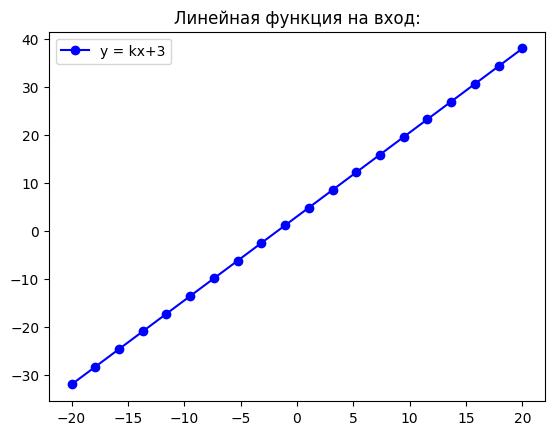

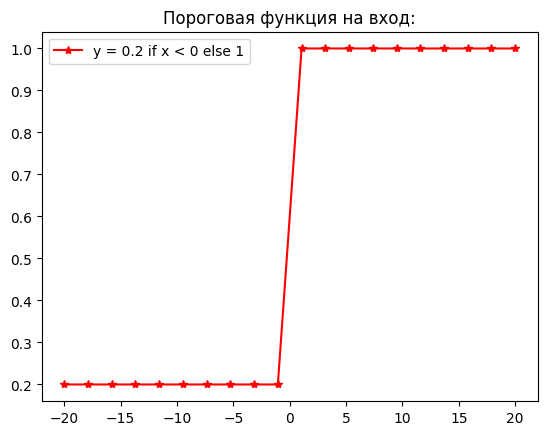

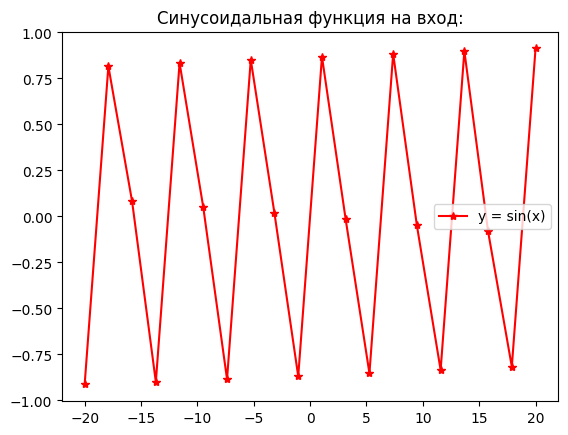

In [ ]:
plt.figure()
plt.title('Линейная функция на вход:')
plt.plot(vx, Xx[0], 'bo-', label='y = kx+3')
plt.legend()

plt.figure()
plt.title('Пороговая функция на вход:')
plt.plot(vx, Xx[1], 'r*-', label='y = 0.2 if x < 0 else 1')
plt.legend()

plt.figure()
plt.title('Синусоидальная функция на вход:')
plt.plot(vx, Xx[2], 'r*-', label='y = sin(x)')
plt.legend()


### 3.3. Эксперименты с весами

Теперь проведем серию экспериментов, меняя диапазоны случайных весов. Это позволит увидеть, как начальная инициализация влияет на работу сети.

#### 3.3.1. Базовый эксперимент

Запустим моделирование для трех диапазонов весов. На графиках будут показаны выходы сети ($Y_1, Y_2$) для каждого случая.

Обратите внимание, как меняется характер кривых в зависимости от знака весов. Напишите вывод.


--- Диапазон весов: [0, 1] (только возбуждающие) ---


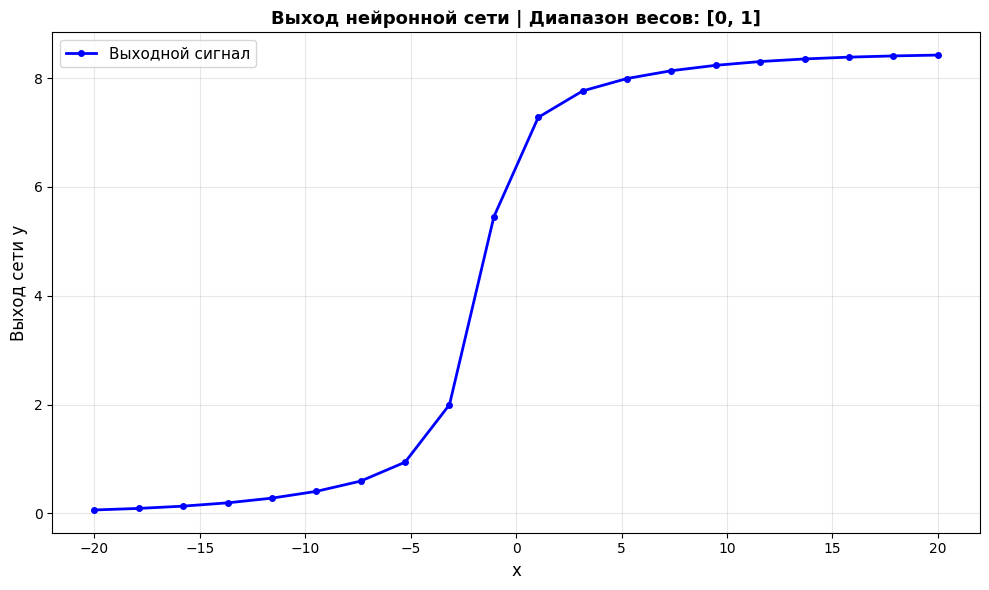


--- Диапазон весов: [-1, 0] (только тормозящие) ---


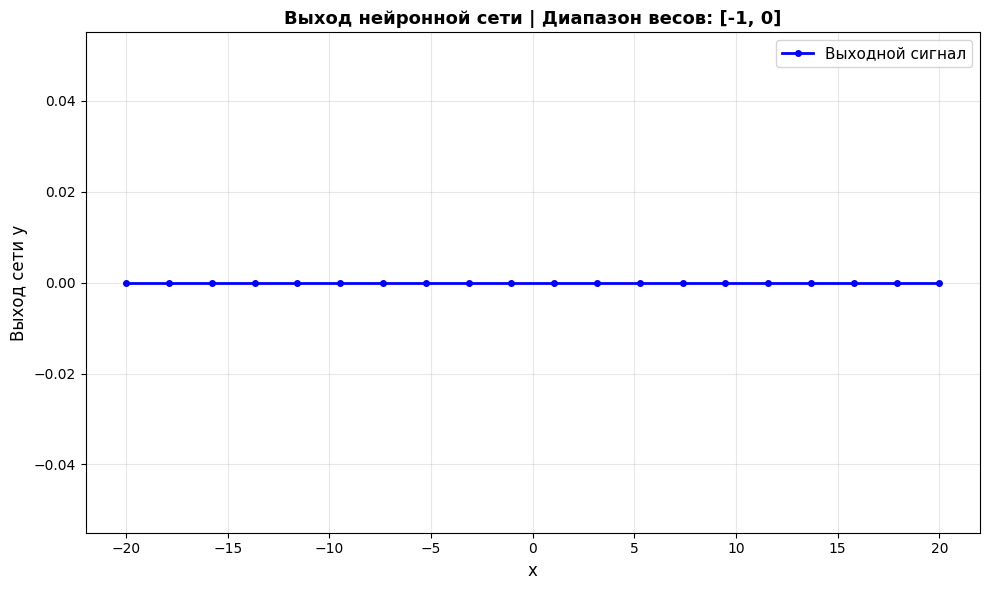


--- Диапазон весов: [-1, 1] (смешанные) ---


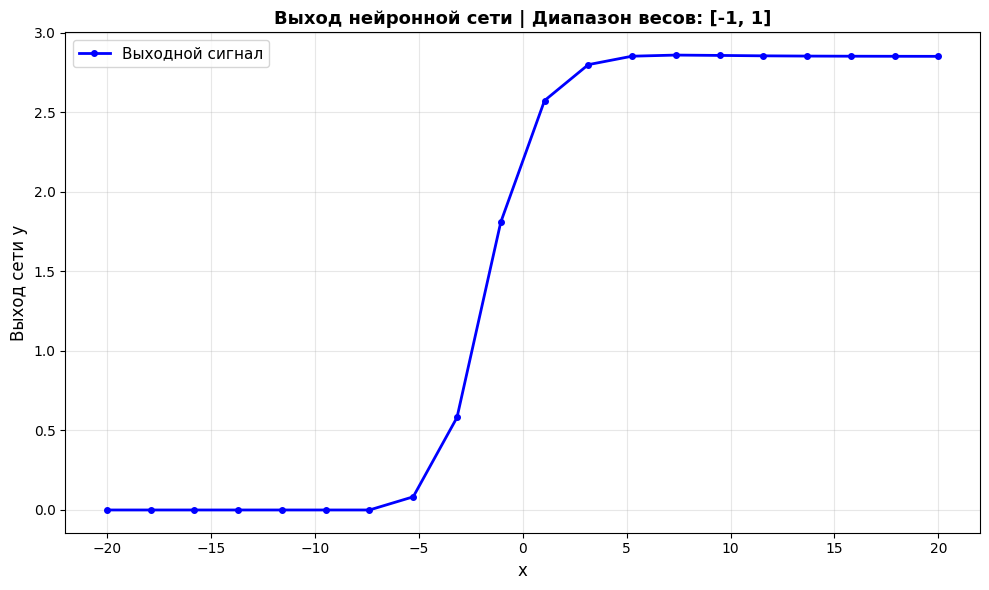

In [ ]:
# Базовые диапазоны
Wes(Xx, vx, a, b)
plt.show()

**Вывод:** При положительных весах формируется монотонное усиливающее преобразование, при смешанных — более гибкое, но сглаженное, а при отрицательных весах сумма вкладов скрытых нейронов становится отрицательной и ReLU почти полностью обнуляет выход, из-за чего сеть фактически «гасится».

#### 3.3.2. Эксперимент с уменьшением весов в 10 раз

Запустите код ниже. Веса уменьшатся в 10 раз (диапазоны $[-0.1; 0]$, $[-0.1; 0.1]$, $[0; 0.1]$).

Обратите внимание, как меняется характер кривых в зависимости от изменения весов. Напишите вывод.


--- Диапазон весов: [0, 0.1] (только возбуждающие) ---


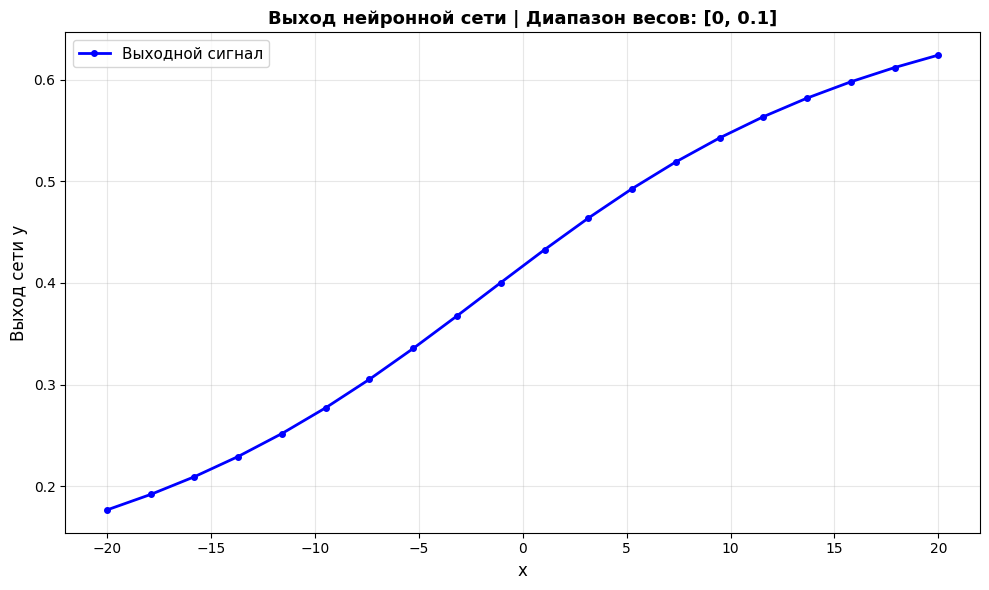


--- Диапазон весов: [-0.1, 0] (только тормозящие) ---


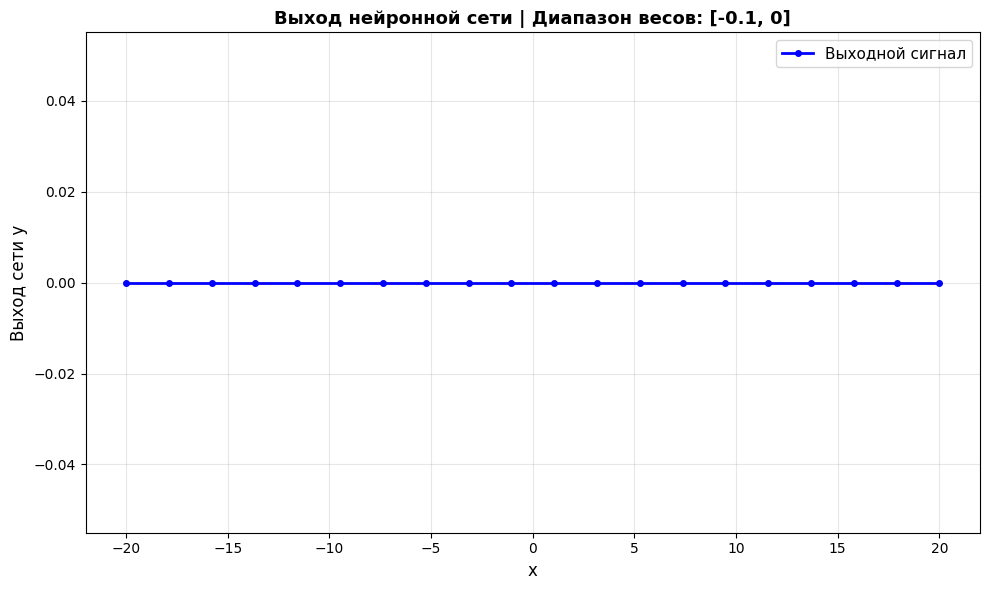


--- Диапазон весов: [-0.1, 0.1] (смешанные) ---


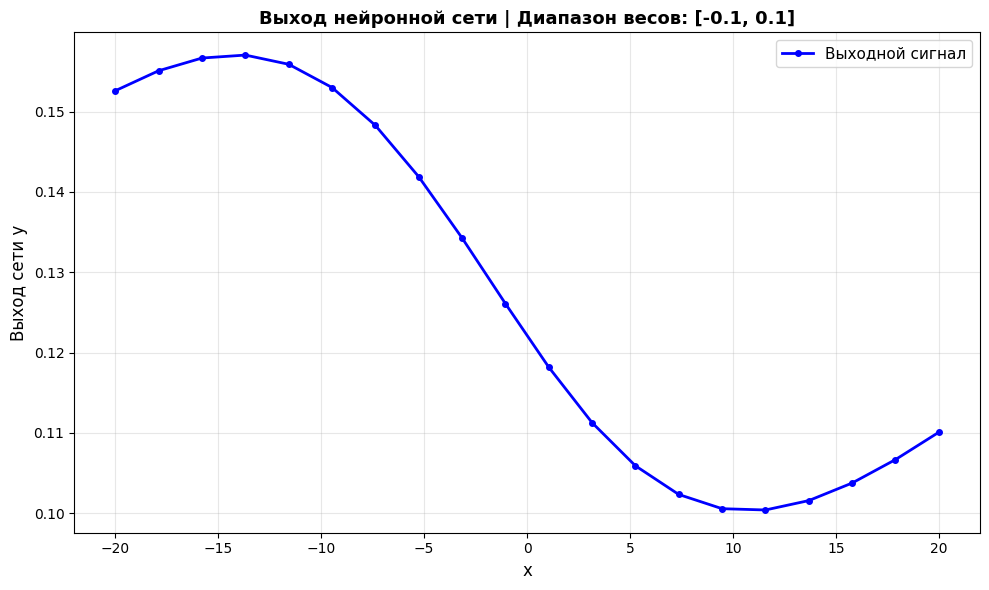

In [ ]:
# Уменьшение весов в 10 раз
Wes(Xx, vx, a/10, b/10)
plt.show()

**Вывод:** Малые веса переводят сигмоидные нейроны в линейный режим работы, поэтому сеть теряет выраженную нелинейность и начинает вести себя почти как линейный преобразователь с последующим обрезанием отрицательной части через ReLU; знак весов остаётся критическим фактором — положительные дают слабый монотонный отклик, смешанные создают небольшие плавные вариации, а отрицательные почти полностью подавляют выход.

#### 3.3.3. Эксперимент с увеличением весов в 10 раз

Запустите код ниже. Веса увеличатся в 10 раз (диапазоны $[-10; 0]$, $[-10; 10]$, $[0; 10]$).

Обратите внимание, как меняется характер кривых в зависимости от изменения весов. Напишите вывод.



--- Диапазон весов: [0, 10] (только возбуждающие) ---


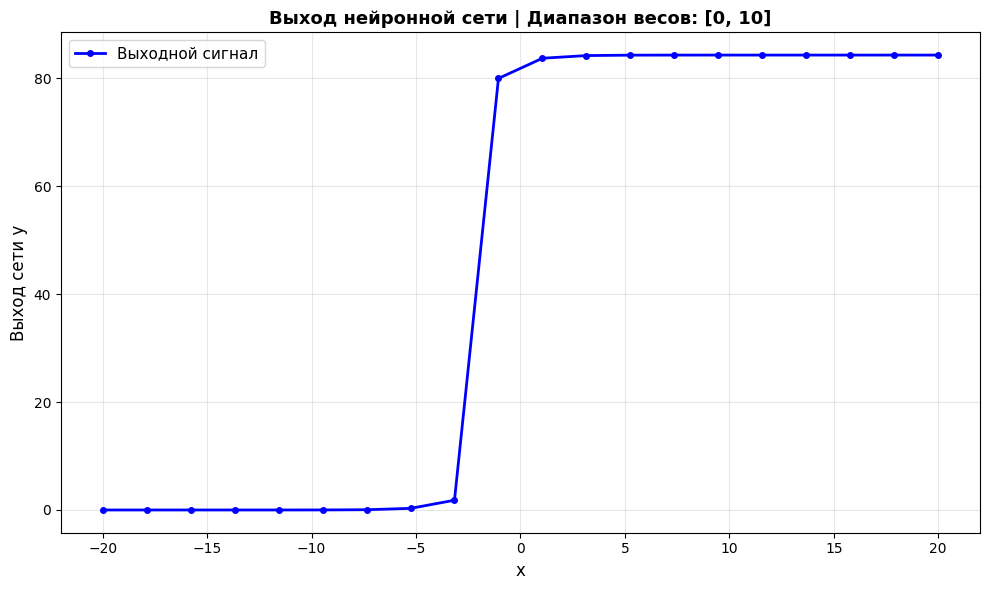


--- Диапазон весов: [-10, 0] (только тормозящие) ---


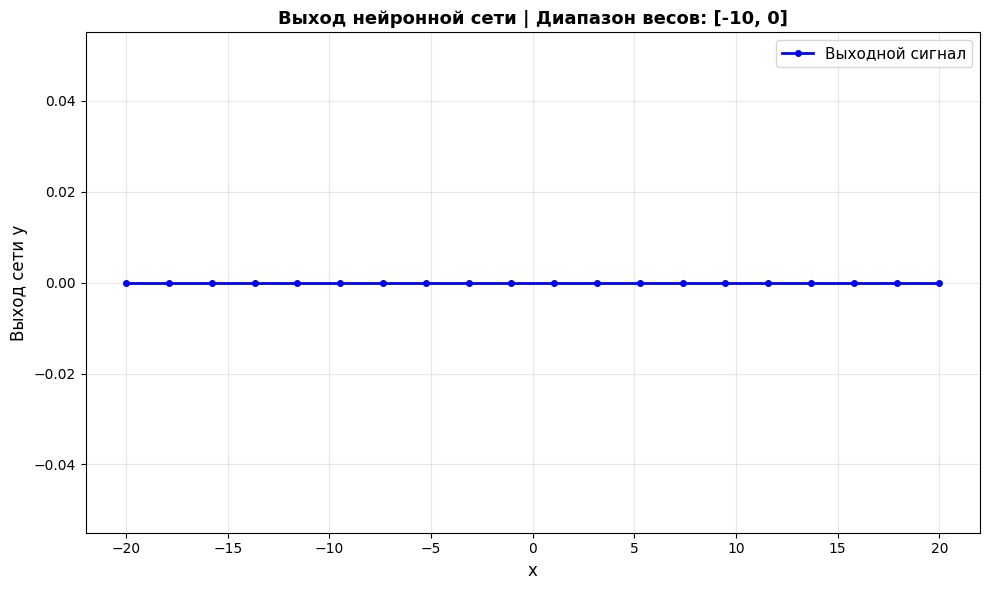


--- Диапазон весов: [-10, 10] (смешанные) ---


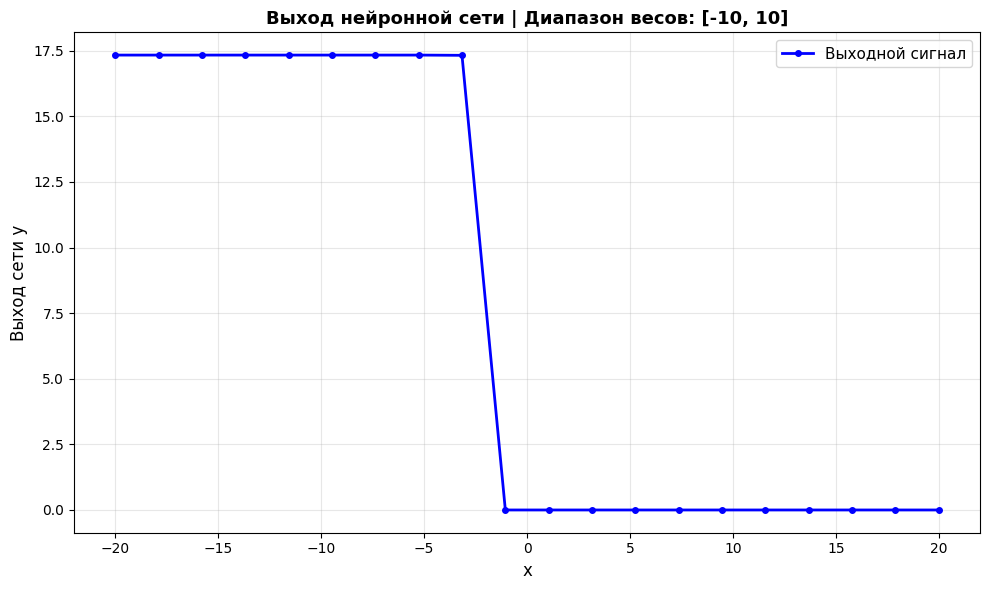

In [ ]:
# Увеличение весов в 10 раз
Wes(Xx, vx, a*10, b*10)
plt.show()

**Вывод:** Большие веса переводят сигмоидные нейроны в режим насыщения, из-за чего скрытый слой фактически превращается в набор почти бинарных пороговых элементов; сеть начинает работать как жёсткий переключатель с резкими скачками выхода и большой амплитудой. При положительных весах формируется мощная ступенчатая зависимость, при смешанных — резкий переход между высоким уровнем и нулём, а при отрицательных — сильная отрицательная сумма полностью обрезается ReLU, делая выход равным нулю на всём диапазоне.

### 4. Общий вывод

В ходе работы показано, что диапазон начальных весов существенно влияет на форму выходного сигнала сети. Положительные веса формируют монотонные усиливающие зависимости, отрицательные — приводят к отрицательной сумме на выходе скрытого слоя, которая полностью обрезается ReLU и даёт нулевой результат. Малые по модулю веса делают сеть почти линейной (сигмоиды работают в центральной области), тогда как большие веса переводят нейроны в режим насыщения и превращают выход в резкую, почти пороговую функцию с высокой амплитудой. Таким образом, знак весов определяет направление и наличие сигнала, а их масштаб — степень нелинейности и «жёсткость» преобразования.

### 5. Контрольные вопросы

1.  **Понятие нейрона. Его математическая модель.** (Из каких основных блоков состоит искусственный нейрон?)
2.  **Нейронная сеть.** (Что это такое и зачем нужно объединять нейроны?)
3.  **Свойства сигмоидальной функции активации.** (Почему она так популярна? Какой у нее диапазон значений?)
4.  **Области применения НС.** (Назовите 2-3 задачи, где нейросети работают лучше обычных алгоритмов).
5.  **Однослойные и многослойные НС.** (В чем главное отличие по возможностям решения задач?)
6.  **Линейность vs Нелинейность.** (В чем принципиальная разница между линейной функцией активации и нелинейной (например, сигмоидой)? Почему для решения сложных задач необходима нелинейность?)